In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, os
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
# Load your data again
features = pd.read_csv('../features.csv')
targets = pd.read_csv('../targets.csv')

data = features.merge(targets[['study_id','patient_id','case_ISUP']], on='study_id')

# Define predictors and target
X = data.drop(['study_id','case_ISUP'], axis=1)
y = data['case_ISUP']


In [3]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

df = X.copy()
df['label'] = y

# Compute target per class
N = len(df)
T = N // 6
print("Target per class:", T)

# -----------------------------
# STEP 1: Fill minority classes using class 0
# -----------------------------
idx_class0 = df[df['label'] == 0].index
used = set()

for cls in range(1, 6):
    current = (df['label'] == cls).sum()
    needed = T - current
    print(f"Class {cls} needs {needed}")
    
    if needed <= 0:
        continue
    
    cls_idx = df[df['label'] == cls].index
    knn = NearestNeighbors(n_neighbors=1)
    knn.fit(df.loc[cls_idx, X.columns])
    
    distances, indices = knn.kneighbors(df.loc[idx_class0, X.columns])
    sorted_idx = np.argsort(distances.flatten())
    
    selected = []
    for i in sorted_idx:
        idx0 = idx_class0[i]
        if idx0 not in used:
            selected.append(idx0)
            used.add(idx0)
        if len(selected) == needed:
            break
    
    df.loc[selected, 'label'] = cls



# Final balanced dataset
print("\nFinal balanced counts:")
print(df['label'].value_counts().sort_index())

X_balanced = df.drop(columns=['label'])
y_balanced = df['label']


Target per class: 171
Class 1 needs 14
Class 2 needs 17
Class 3 needs 102
Class 4 needs 144
Class 5 needs 136

Final balanced counts:
label
0    176
1    171
2    171
3    171
4    171
5    171
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42
)


In [5]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1,1)).ravel()


In [6]:
model = LinearRegression()
model.fit(X_train_scaled, y_train_scaled)

y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()

print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


MSE: 2.8003743204996114
R²: 0.052335813780699625


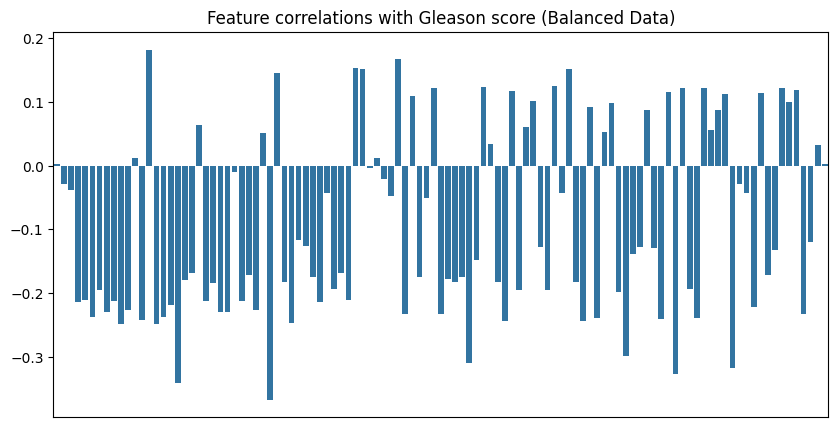

In [7]:
corrs = X_balanced.corrwith(y_balanced)
plt.figure(figsize=(10,5))
sns.barplot(x=corrs.index, y=corrs.values)
plt.xticks([])
plt.xlabel("")
plt.title("Feature correlations with Gleason score (Balanced Data)")
plt.show()


In [8]:
selector = SelectKBest(score_func=f_regression, k=10)
X_selected = selector.fit_transform(X_balanced, y_balanced)
selected_features = X_balanced.columns[selector.get_support()]
print("Selected features (ANOVA):", selected_features.tolist())

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_balanced[selected_features], y_balanced, test_size=0.2, random_state=42
)

scaler_X_sel = StandardScaler()
X_train_sel_scaled = scaler_X_sel.fit_transform(X_train_sel)
X_test_sel_scaled  = scaler_X_sel.transform(X_test_sel)

scaler_y_sel = StandardScaler()
y_train_sel_scaled = scaler_y_sel.fit_transform(y_train_sel.values.reshape(-1,1)).ravel()
y_test_sel_scaled  = scaler_y_sel.transform(y_test_sel.values.reshape(-1,1)).ravel()

lr = LinearRegression()
lr.fit(X_train_sel_scaled, y_train_sel_scaled)
y_pred_sel_scaled = lr.predict(X_test_sel_scaled)
y_pred_sel = scaler_y_sel.inverse_transform(y_pred_sel_scaled.reshape(-1,1)).ravel()

print("\n--- Linear Regression (ANOVA-selected features, balanced) ---")
print("MSE:", mean_squared_error(y_test_sel, y_pred_sel))
print("R²:", r2_score(y_test_sel, y_pred_sel))


Selected features (ANOVA): ['original_shape_MeshVolume', 'original_shape_VoxelVolume', 'original_firstorder_Energy', 'original_firstorder_TotalEnergy', 'original_glcm_Autocorrelation', 'original_gldm_DependenceNonUniformity', 'original_gldm_HighGrayLevelEmphasis', 'original_glrlm_RunLengthNonUniformity', 'original_glszm_GrayLevelNonUniformity', 'original_glszm_SizeZoneNonUniformity']

--- Linear Regression (ANOVA-selected features, balanced) ---
MSE: 2.523462651488233
R²: 0.14604445463892535


In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_balanced)

X_train_lasso, X_test_lasso, y_train_lasso, y_test_lasso = train_test_split(
    X_scaled, y_balanced, test_size=0.2, random_state=42
)

lasso = LassoCV(
    cv=5,
    random_state=42,
    max_iter=50000,
    tol=1e-4,
    alphas=np.logspace(-3, 1, 50)
).fit(X_train_lasso, y_train_lasso)

y_pred_lasso = lasso.predict(X_test_lasso)

print("\n--- Lasso Regression (balanced predictors) ---")
print("MSE:", mean_squared_error(y_test_lasso, y_pred_lasso))
print("R²:", r2_score(y_test_lasso, y_pred_lasso))
print("Number of selected features:", np.sum(lasso.coef_ != 0))

selected_by_lasso = X_balanced.columns[lasso.coef_ != 0]
print("Selected features:", selected_by_lasso.tolist())


/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.728e-01, tolerance: 1.941e-01
  model = cd_fast.enet_coordinate_descent_gram(
/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.717e-01, tolerance: 1.941e-01
  model = cd_fast.enet_coordinate_descent_gram(



--- Lasso Regression (balanced predictors) ---
MSE: 2.506481493000856
R²: 0.15179098488711384
Number of selected features: 5
Selected features: ['original_firstorder_Kurtosis', 'original_firstorder_TotalEnergy', 'original_gldm_DependenceNonUniformity', 'original_glszm_GrayLevelNonUniformity', 'original_glszm_ZoneVariance']
